<a href="https://colab.research.google.com/github/turryhit/data-analytics-public/blob/main/2026_04_30__Capstone_Project_Python_Winter_2026_You_Dirty_Rat_(H_Turry).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# You Dirty Rat: Exploring NYC Rodent Inspections Over Time

This analysis explores NYC rodent inspection data to examine how inspection activity and outcomes changed over time, focusing on three key periods: pre-COVID (2010–2020), the COVID/recovery period (2020–2022), and the post–rat czar period beginning in 2023, alongside major waste policy changes that have been implemented by city government.

**Introduction and Motivation**

I chose this topic since I have been a resident of NYC since I was born, and I know first hand how the abundance of rodents negatively impacts my quality of life. It is also a matter of public health -- whether it is on the subway tracks, in housing, at work, dining out or simply walking in our own neighborhoods, we should be informed about the what the administration is doing with respect to the rodent population.

**Research Question / Problem Statement**

How have rodent inspection activity and outcomes changed across three time periods:  pre-COVID (2010–2020), COVID/recovery (2020–2022), and post–rat czar (2023-2026)?

**Data Source**

The dataset used in this analysis comes from NYC Open Data and was published by the New York City Department of Health and Mental Hygiene (DOHMH). The dataset is publicly available at the following URL:

[https://www.google.com/url?q=https%3A%2F%2Fwww.google.com%2Furl%3Fq%3Dhttps%253A%252F%252Fdata.cityofnewyork.us%252Fd%252Fp937-wjvj](https://www.google.com/url?q=https%3A%2F%2Fwww.google.com%2Furl%3Fq%3Dhttps%253A%252F%252Fdata.cityofnewyork.us%252Fd%252Fp937-wjvj)

As of this writing, the full dataset contains 3.04M rows, 25 Columns and is updated daily. Each row is a
Rodent Inspection.

I limited my analysis to the rows with Inspection Dates from the years 2010-2026.

**References**

To support my work I utilized the following references to better understand the data and activity policies:

[User Guide _ NYC Rat Inspections Final August 2020.pdf](https://data.cityofnewyork.us/api/views/p937-wjvj/files/460f156c-8650-4b6c-828c-f996a69e3218?download=true&filename=User%20Guide%20_%20%20NYC%20Rat%20Inspections%20Final%20August%202020.pdf)

[DOHMHDataDictionary_NYCRodentInspection_August2020.xlsx](https://data.cityofnewyork.us/api/views/p937-wjvj/files/eac35c24-ea19-4170-aa90-6de10146e8c9?download=true&filename=DOHMHDataDictionary_NYCRodentInspection_August2020.xlsx)

[Rat Information Portal](https://a816-dohbesp.nyc.gov/IndicatorPublic/rats/)

[Mayor Adams Anoints Kathleen Corradi as NYC's First-Ever 'Rat Czar'](https://www.nyc.gov/mayors-office/news/2023/04/mayor-adams-anoints-kathleen-corradi-nyc-s-first-ever-rat-czar)

April 12, 2023 (NYC.gov)

[Rats run this city: NYC czar leaves position without so much as a squeak](https://www.fox5ny.com/news/nyc-rat-czar-adams-rodent-streets-resign)

September 24, 2025 (Fox 5)

[Mayor Adams Signs Executive Order Establishing Office of Rodent Mitigation](https://www.nyc.gov/mayors-office/news/2025/12/mayor-adams-signs-executive-order-establishing-office-of-rodent-)

December 17, 2025 (NYC.gov)

**Python Libraries**

**pandas** - allows for data manipulation and analysis of DataFrames

**datetime** - module providing classes for manipulating dates and times

**numpy**: allows for numerical computing

**matplotlib**: allows for creating visualizations.

**seaborn**: library based on Matplotlib that provides a high-level interface for visualizations

**os**: utility module allowing Python scripts to interact with the underlying OS regardless of whether you are on Windows, macOS, or Linux;
used for file directory listing

**urllib.parse**: module used to break Uniform Resource Locator (URL) strings into components or to combine components back into a URL string; allows for URL manipulation and quoting

**google.colab**: package used to interact with the Google Colab environment; Allows for uploading/downloading files from/to your local machine, and interacting with the browser's UI

In [ ]:
# Python Libraries
import pandas as pd
import datetime as dt
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator
from urllib.parse import quote
from google.colab import files

print("Libraries imported successfully.")

Libraries imported successfully.


**Loading and Preparing the Dataset**

Data was retrieved in batches of 50,000 rows using pagination due to dataset size.

Note: when last executed this took about 20 minutes to complete and loaded approximately 60 pages (3 million rows)

After loading, I saved the dataset as a CSV to improve efficiency and resproducibility for the Capstone project.

Initial exploratory analysis was conducted to understand structure, data quality, and relevant fields. The steps below reflect the finalized data preparation and analysis flow.

## Load the dataset from NYC Open Data

In [ ]:
# read the dataset in chunks of 50,000 rows at a time
# use a while loop to add each page of data to the dataframe using concat

df = pd.DataFrame()
page = 0
# set the date range of inspections to get for the analysis
from_date = '2010-01-01'
to_date = '2026-12-31'

now = dt.datetime.now(dt.timezone.utc)
print(f"{now}: Starting data load....")
while True: # keep retrieving/adding pages to the dataframe until there are no more left
  query = f"""
  SELECT
    inspection_type,
    job_ticket_or_work_order_id,
    job_id,
    job_progress,
    bbl,
    boro_code,
    block,
    lot,
    house_number,
    street_name,
    zip_code,
    x_coord,
    y_coord,
    latitude,
    longitude,
    borough,
    inspection_date,
    result,
    approved_date,
    location,
    community_board,
    council_district,
    census_tract,
    bin,
    nta
  WHERE
        inspection_date >= '{from_date}'
    AND inspection_date <= '{to_date}'
    AND inspection_date IS NOT NULL
  ORDER BY
    job_ticket_or_work_order_id,
    inspection_type
  LIMIT 50000
  OFFSET {50_000 * page}
  """

  URL = f"https://data.cityofnewyork.us/resource/p937-wjvj.csv?$query={quote(query)}"
  sub_df = pd.read_csv(URL)

  if len(sub_df) == 0:
    break

  df = pd.concat([df, sub_df], axis=0, ignore_index=True)
  # display progress of building the dataset - for testing only
  # now = dt.datetime.now(dt.timezone.utc)
  # print(f"{now} Page {page}: {len(sub_df):,} rows")
  page += 1

now = dt.datetime.now(dt.timezone.utc)
print(f"{now}: Data loaded successfully 50,000 rows at a time:\n {page-1} pages")
df.shape

2026-04-27 17:21:06.434346+00:00: Starting data load....
2026-04-27 17:42:28.993136+00:00: Data loaded successfully 50,000 rows at a time:
 60 pages


(3019255, 25)

In [ ]:
# save the dataset as a csv so that I don't have to load it from the NYC Open Data API and I can work with a static set of data for analysis
# df.to_csv("rodent_data_full_2010_2026.csv", index=False)

In [ ]:
# download the csv to my local drive so that I can upload it to colab in future sessions
# files.download("rodent_data_full_2010_2026.csv")

In [ ]:
# see what files are currently available in the colab session
# os.listdir()

In [ ]:
# Create a copy of the dataframe to prepare for analysis
is_test = False
if is_test:
  df_raw = pd.read_csv("rodent_data_full_2010_2026.csv") # saved on my local drive and uploaded to google colab
else:
  df_raw = df.copy() # read from NYC Open Data

## Checking and Cleaning the Data

##### Check Datatypes

In [ ]:
# Check data types and non-null counts to help identify which fields may need cleaning or conversion before analysis.
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3019255 entries, 0 to 3019254
Data columns (total 25 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   inspection_type              object 
 1   job_ticket_or_work_order_id  int64  
 2   job_id                       object 
 3   job_progress                 int64  
 4   bbl                          float64
 5   boro_code                    float64
 6   block                        float64
 7   lot                          float64
 8   house_number                 object 
 9   street_name                  object 
 10  zip_code                     float64
 11  x_coord                      float64
 12  y_coord                      float64
 13  latitude                     float64
 14  longitude                    float64
 15  borough                      object 
 16  inspection_date              object 
 17  result                       object 
 18  approved_date                object 
 19  

##### Check for null values

In [ ]:
# Check for null values

print("These are the columns with null values:")
df_raw.isnull().sum().sort_values(ascending = False)

These are the columns with null values:


,0
y_coord,945695
x_coord,945695
bin,100128
bbl,100128
community_board,80253
council_district,80253
nta,80253
census_tract,80253
house_number,52111
location,24437


In [ ]:
# further analyzed the columns with nulls to see what percentage of the total number of rows they are

(df_raw.isnull().sum() / len(df_raw) * 100).round(5).sort_values(ascending=False)

,0
y_coord,31.32213
x_coord,31.32213
bin,3.31631
bbl,3.31631
community_board,2.65804
council_district,2.65804
nta,2.65804
census_tract,2.65804
house_number,1.72596
location,0.80937


### Missing values visualization

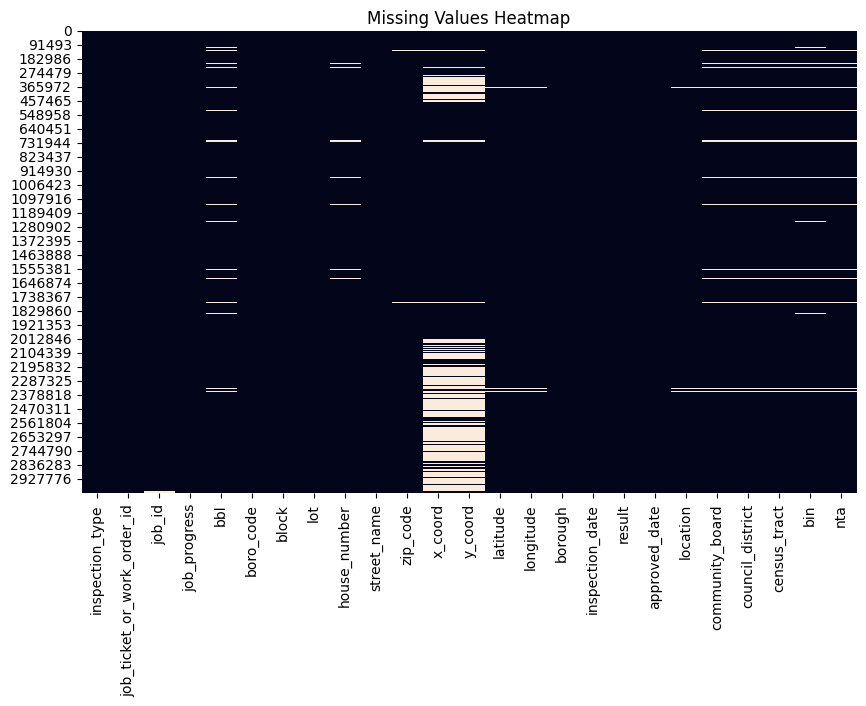

In [ ]:
# Create a heat map showing the missing values

plt.figure(figsize=(10,6))
sns.heatmap(df_raw.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

### Create df_clean

In [ ]:
# create df_clean from df_raw
df_clean = df_raw.copy()

#### Drop unnecessary columns

In [ ]:
# drop columns that I will not be using for this analysis
df_clean = df_clean.drop(columns = ["x_coord", "y_coord", "bin", "nta"])
df_clean.columns
print(f"Dropped columns: {["x_coord", "y_coord", "bin", "nta"]}")

Dropped columns: ['x_coord', 'y_coord', 'bin', 'nta']


#### Analyze and Remove the rows with no borough or invalid boro_code

In [ ]:
# further analyzing the rows with no borough
is_invalid_borough = df_raw["borough"].isnull()
df_invalid_borough = df_raw[is_invalid_borough]
print(f"There are {len(df_invalid_borough):,} rows with a missing borough. The boro_code(s) are:")
print(df_invalid_borough["boro_code"].unique())
print()

boro_codes_full = list(df_raw["boro_code"].sort_values().unique())
print(f"The list of unique boro_codes in the full dataset is:")
for boro_code in boro_codes_full:
  print(boro_code)

There are 333 rows with a missing borough. The boro_code(s) are:
[ 9. nan]

The list of unique boro_codes in the full dataset is:
1.0
2.0
3.0
4.0
5.0
9.0
nan


In [ ]:
# drop the rows with the null borough
# (boro_code 9 is not valid - there are only 5 boroughs in NYC)
is_invalid_borough = df_clean["borough"].isnull()
print()
print(f"Before cleaning, there are {len(df_clean[is_invalid_borough]):,} rows with a missing borough out of a total of {len(df_clean):,} rows in the dataframe.")
print()

# filter out the rows with null borough
df_clean = df_clean[~is_invalid_borough]
is_invalid_borough = df_clean["borough"].isnull()

print(f"After cleaning, there are {len(df_clean[is_invalid_borough]):,} rows with a missing borough out of a total of {len(df_clean):,} rows in the dataframe.")
print(df_clean["boro_code"].sort_values().unique())
print(f"The clean df now has only rows with valid boroughs:\n {df_clean["borough"].value_counts(dropna=False)}")


Before cleaning, there are 333 rows with a missing borough out of a total of 3,019,255 rows in the dataframe.

After cleaning, there are 0 rows with a missing borough out of a total of 3,018,922 rows in the dataframe.
[1. 2. 3. 4. 5.]
The clean df now has only rows with valid boroughs:
 borough
Manhattan        968949
Brooklyn         906523
Bronx            831641
Queens           246102
Staten Island     65707
Name: count, dtype: int64


#### Check for duplicate rows

In [ ]:
# The data dictionary indicates the unique key is a composite of two columns: inspection_type and job_ticket_or_work_order_id
print("Total of exact duplicate rows:", df_clean.duplicated().sum())
df_clean.duplicated(subset=["job_ticket_or_work_order_id", "inspection_type"]).sum()

Total of exact duplicate rows: 0


np.int64(0)

### Transformations

#### Convert the date columns from python "objects" to pandas datetimes (UTC) for time series analysis

In [ ]:
# convert inspection_date and approved_date to datetime

print(f"Before conversion, the columns have the following datatypes:\n{df_clean.dtypes.sort_values()}")
print()

col_name = "inspection_date"
df_clean[col_name] = pd.to_datetime(df_clean[col_name], utc=True)
print(f"After conversion, the {col_name} column has the following datatype:\n{df_clean[col_name].dtype}")

col_name = "approved_date"
df_clean[col_name] = pd.to_datetime(df_clean[col_name], utc=True)
print(f"After conversion, the {col_name} column has the following datatype:\n{df_clean[col_name].dtype}")

Before conversion, the columns have the following datatypes:
job_ticket_or_work_order_id      int64
job_progress                     int64
zip_code                       float64
community_board                float64
longitude                      float64
latitude                       float64
council_district               float64
census_tract                   float64
block                          float64
boro_code                      float64
bbl                            float64
lot                            float64
house_number                    object
street_name                     object
borough                         object
inspection_date                 object
result                          object
approved_date                   object
location                        object
job_id                          object
inspection_type                 object
dtype: object

After conversion, the inspection_date column has the following datatype:
datetime64[ns, UTC]
After conver

### Functions (custom-defined)

#### This function was created to avoid repeating similar groupby logic across multiple analyses.

This function, named "aggregate_inspection_data", will group a dataframe by one or more columns, aggregate one column using count or sum, reset the index, and return a clean dataframe according to the parameters input.

In [ ]:
# Create function aggregate_inspection_data
"""
  This function will group a dataframe by one or more columns, aggregate one column using count or sum, reset the index, and return a clean dataframe according to the parameters input.
"""
def aggregate_inspection_data(
    df: pd.DataFrame,
    grouping_columns: list, # list of column name strings existing in the df
    summary_column: str,    # column name existing in the df
    aggregation_type: str,  # "count" or "sum"
    output_column_name: str # column name for the column that will be calculated
) -> pd.DataFrame:

  # check to see if we have any data
  if len(df) == 0:
    print(f"Invalid input: The dataframe has no rows to aggregate.\n {df}")
    return

  # check the aggregation type
  valid_aggregation_types = ["count", "sum"]
  if aggregation_type.lower() in valid_aggregation_types:
    pass
  else:
    print(f"This function can only aggregate by count or sum. Invalid input:\n {aggregation_type}")
    return

  df_raw = df
  # create a new dataframe with the rows grouped as requested

  print(f"Grouping the dataframe by {grouping_columns} to {aggregation_type} values in {summary_column} with output column {output_column_name}")

  if aggregation_type == "count":
    df_grouped = (
      df_raw
      .groupby(grouping_columns)[summary_column]
      .count()
      .reset_index(name=output_column_name, drop=False)
      )
  else:
    df_grouped = (
      df_raw
      .groupby(grouping_columns)[summary_column]
      .sum()
      .reset_index(name = output_column_name, drop=False)
      )
  return df_grouped

# Analyze the data

#### Create a new dataframe for the Analysis of inspections over time

In [ ]:
# for reusability, creating a copy of the raw data to clean do preliminary analysis
df_rodents = df_clean.copy()

In [ ]:
# confirm we can now easily reference the rows by inspection_date time periods
is_pre_covid = df_rodents["inspection_date"] < "2020-03" # before March 2020
pre_covid_count = len(df_rodents[is_pre_covid])
print(f"There are {pre_covid_count:,} inspections from the pre-covid time period")
start_row = df_rodents[is_pre_covid].inspection_date.min()
end_row = df_rodents[is_pre_covid].inspection_date.max()
print(f"They span from: {start_row} to: {end_row}")
# df_rodents[is_pre_covid].value_counts("inspection_date").sort_values(ascending = False)

There are 1,858,359 inspections from the pre-covid time period
They span from: 2010-01-01 10:21:00+00:00 to: 2020-02-29 17:00:44+00:00


#### Create a new "time_period" column and assign one of the three Time Period categories to each row for analysis

In [ ]:
# creating a new data frame for analysis purposes
df_rodents_by_time = df_rodents.copy()

# create the time_period column
# assign each row one of the three time period categories based on the inspection date
"""
"Pre-COVID" - before March 2020
"COVID / Recovery" - before April 2023
"Post Rat Czar" - everything else to the present
"""
# use numpy select to define and set the conditions and categories
df_rodents_by_time["time_period"] = np.select(
    [
        df_rodents_by_time["inspection_date"] < "2020-03",
        df_rodents_by_time["inspection_date"] < "2023-04"
    ],
    [
        "Pre-COVID",
        "COVID / Recovery"
    ],
    default="Post Rat Czar"
  )

In [ ]:
# checking the new column was added
print(f"After adding time_period column:\n")
df_rodents_by_time.shape

After adding time_period column:



(3018922, 22)

In [ ]:
# checking that all rows were assigned a valid time_period
# df_rodents_by_time.value_counts("time_period", dropna=False).sort_values(ascending=False)

In [ ]:
# quick spot check of most recent inspection dates
df_rodents_by_time[["inspection_date","time_period"]].sort_values("inspection_date").tail(3)

,inspection_date,time_period
3002016,2026-04-24 14:05:43+00:00,Post Rat Czar
3001997,2026-04-24 14:40:00+00:00,Post Rat Czar
3002017,2026-04-25 09:29:26+00:00,Post Rat Czar


In [ ]:
# quick spot check of oldest inspection dates
df_rodents_by_time[["inspection_date","time_period"]].sort_values("inspection_date").head(3)

,inspection_date,time_period
828,2010-01-01 10:21:00+00:00,Pre-COVID
1746953,2010-01-04 08:00:26+00:00,Pre-COVID
631159,2010-01-04 08:24:34+00:00,Pre-COVID


##### Perform boundary checks on the time period categories

In [ ]:
# check dates at the boundaries of the time period categories
"""
Pick an inspection date in:

  late Feb 2020
  early March 2020
  late March 2023
  early April 2023

Then confirm:

  Feb 2020 -  Pre-COVID
  March 2020 - COVID / Recovery
  March 2023 - COVID / Recovery
  April 2023 - Post Rat Czar

"""

date_to_check = pd.to_datetime("2020-02-29").date()
boundary_time_period = "Pre-COVID"

print(f"Checking {date_to_check} is {boundary_time_period}:")
is_date_to_check = df_rodents_by_time["inspection_date"].dt.date == date_to_check
df_rodents_by_time[is_date_to_check][["inspection_date","time_period"]].sort_values("inspection_date").head(1)

Checking 2020-02-29 is Pre-COVID:


,inspection_date,time_period
283649,2020-02-29 07:00:44+00:00,Pre-COVID


In [ ]:
# check dates at the boundaries of the time period categories
"""
Pick an inspection date in:

  late Feb 2020
  early March 2020
  late March 2023
  early April 2023

Then confirm:

  Feb 2020 -  Pre-COVID
  March 2020 - COVID / Recovery
  March 2023 - COVID / Recovery
  April 2023 - Post Rat Czar

"""

# date_to_check = pd.to_datetime("2020-03-01").date()
# boundary_time_period = "COVID/Recovery"

# print(f"Checking {date_to_check} is {boundary_time_period}:")
# is_date_to_check = df_rodents_by_time["inspection_date"].dt.date == date_to_check
# df_rodents_by_time[is_date_to_check][["inspection_date","time_period"]].sort_values("inspection_date").head(1)

'\nPick an inspection date in:\n\n  late Feb 2020\n  early March 2020\n  late March 2023\n  early April 2023\n\nThen confirm:\n\n  Feb 2020 -  Pre-COVID\n  March 2020 - COVID / Recovery\n  March 2023 - COVID / Recovery\n  April 2023 - Post Rat Czar\n\n'

In [ ]:
# check dates at the boundaries of the time period categories
"""
Pick an inspection date in:

  late Feb 2020
  early March 2020
  late March 2023
  early April 2023

Then confirm:

  Feb 2020 -  Pre-COVID
  March 2020 - COVID / Recovery
  March 2023 - COVID / Recovery
  April 2023 - Post Rat Czar

"""

# date_to_check = pd.to_datetime("2023-03-31").date()
# boundary_time_period = "COVID/Recovery"

# print(f"Checking {date_to_check} is {boundary_time_period}:")
# is_date_to_check = df_rodents_by_time["inspection_date"].dt.date == date_to_check
# df_rodents_by_time[is_date_to_check][["inspection_date","time_period"]].sort_values("inspection_date").head(1)

'\nPick an inspection date in:\n\n  late Feb 2020\n  early March 2020\n  late March 2023\n  early April 2023\n\nThen confirm:\n\n  Feb 2020 -  Pre-COVID\n  March 2020 - COVID / Recovery\n  March 2023 - COVID / Recovery\n  April 2023 - Post Rat Czar\n\n'

In [ ]:
# check dates at the boundaries of the time period categories
"""
Pick an inspection date in:

  late Feb 2020
  early March 2020
  late March 2023
  early April 2023

Then confirm:

  Feb 2020 -  Pre-COVID
  March 2020 - COVID / Recovery
  March 2023 - COVID / Recovery
  April 2023 - Post Rat Czar

"""

# date_to_check = pd.to_datetime("2023-04-01").date()
# boundary_time_period = "Post Rat Czar"

# print(f"Checking {date_to_check} is {boundary_time_period}:")
# is_date_to_check = df_rodents_by_time["inspection_date"].dt.date == date_to_check
# df_rodents_by_time[is_date_to_check][["inspection_date","time_period"]].sort_values("inspection_date").head(1)

'\nPick an inspection date in:\n\n  late Feb 2020\n  early March 2020\n  late March 2023\n  early April 2023\n\nThen confirm:\n\n  Feb 2020 -  Pre-COVID\n  March 2020 - COVID / Recovery\n  March 2023 - COVID / Recovery\n  April 2023 - Post Rat Czar\n\n'

## Monthly Aggregation Analysis

### Create a column with the Year+Month of the Inspection Date for grouping of inspection counts by each month in year (all time periods)

In [ ]:
# create a column called inspection_month_period containing the Year and Month of the inspection_date (e.g. "2023-04-06" becomes "2023-04")

# use dt.to_period to convert the inspection date to a month period (time zone info not needed for this analysis)
df_rodents_by_time["inspection_month_period"] = df_rodents_by_time["inspection_date"].dt.to_period("M")

/tmp/ipykernel_1819/129840440.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_rodents_by_time["inspection_month_period"] = df_rodents_by_time["inspection_date"].dt.to_period("M")


In [ ]:
# sanity check the new inspection_month_period column
print("From preliminary analysis we expect the lowest counts in COVID/Recovery months, highest in Pre-Covid & Post Czar months")
# df_rodents_by_time.value_counts("inspection_month_period").sort_values(ascending = True)

From preliminary analysis we expect the lowest counts in COVID/Recovery months, highest in Pre-Covid & Post Czar months


In [ ]:
df_rodents_by_time[["inspection_date", "inspection_month_period", "time_period"]].sort_values("inspection_date").tail(5)

,inspection_date,inspection_month_period,time_period
461343,2026-04-24 13:48:15+00:00,2026-04,Post Rat Czar
461354,2026-04-24 13:51:00+00:00,2026-04,Post Rat Czar
3002016,2026-04-24 14:05:43+00:00,2026-04,Post Rat Czar
3001997,2026-04-24 14:40:00+00:00,2026-04,Post Rat Czar
3002017,2026-04-25 09:29:26+00:00,2026-04,Post Rat Czar


### Create a table of Inspection Counts grouped by Inspection Month period for Analysis and graphs

In [ ]:
# Use the aggregate_inspection_data function to group the rodent inspections by month_period and create a table with aggregate result counts
columns_to_group = ["inspection_month_period"]
type_of_aggregation = "count"
summary_column_name = "inspection_date"
calculated_column_name = "inspection_count"

inspection_counts_by_month = aggregate_inspection_data(
  df = df_rodents_by_time,
  grouping_columns = columns_to_group,
  summary_column = summary_column_name,
  aggregation_type = type_of_aggregation,
  output_column_name = calculated_column_name
  )

print(inspection_counts_by_month)

Grouping the dataframe by ['inspection_month_period'] to count values in inspection_date with output column inspection_count
    inspection_month_period  inspection_count
0                   2010-01              9106
1                   2010-02              8595
2                   2010-03             14780
3                   2010-04             18251
4                   2010-05             13432
..                      ...               ...
191                 2025-12             15974
192                 2026-01             15684
193                 2026-02             12995
194                 2026-03             22082
195                 2026-04             16497

[196 rows x 2 columns]


In [ ]:
inspection_counts_by_month.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype    
---  ------                   --------------  -----    
 0   inspection_month_period  196 non-null    period[M]
 1   inspection_count         196 non-null    int64    
dtypes: int64(1), period[M](1)
memory usage: 3.2 KB


### Visualization - create a line plot to show the monthly inspection activity over all time periods

In [ ]:
# To simplify plotting by month, add a column that has the inspection_month_period as a datetime. Each "inspection_month_date" will be first day of that inspection_month_period
# for example, if the inspection_month_period is 2025-04, the inspection_month_date will be 2025-04-01

inspection_counts_by_month["inspection_month_date"] = pd.to_datetime(inspection_counts_by_month["inspection_month_period"].astype(str))

In [ ]:
# Here is the table of monthly inspection counts over all years to use for plotting
inspection_counts_by_month

,inspection_month_period,inspection_count,inspection_month_date
0,2010-01,9106,2010-01-01
1,2010-02,8595,2010-02-01
2,2010-03,14780,2010-03-01
3,2010-04,18251,2010-04-01
4,2010-05,13432,2010-05-01
...,...,...,...
191,2025-12,15974,2025-12-01
192,2026-01,15684,2026-01-01
193,2026-02,12995,2026-02-01
194,2026-03,22082,2026-03-01


#### Create a line plot of monthly inspection counts over all time periods

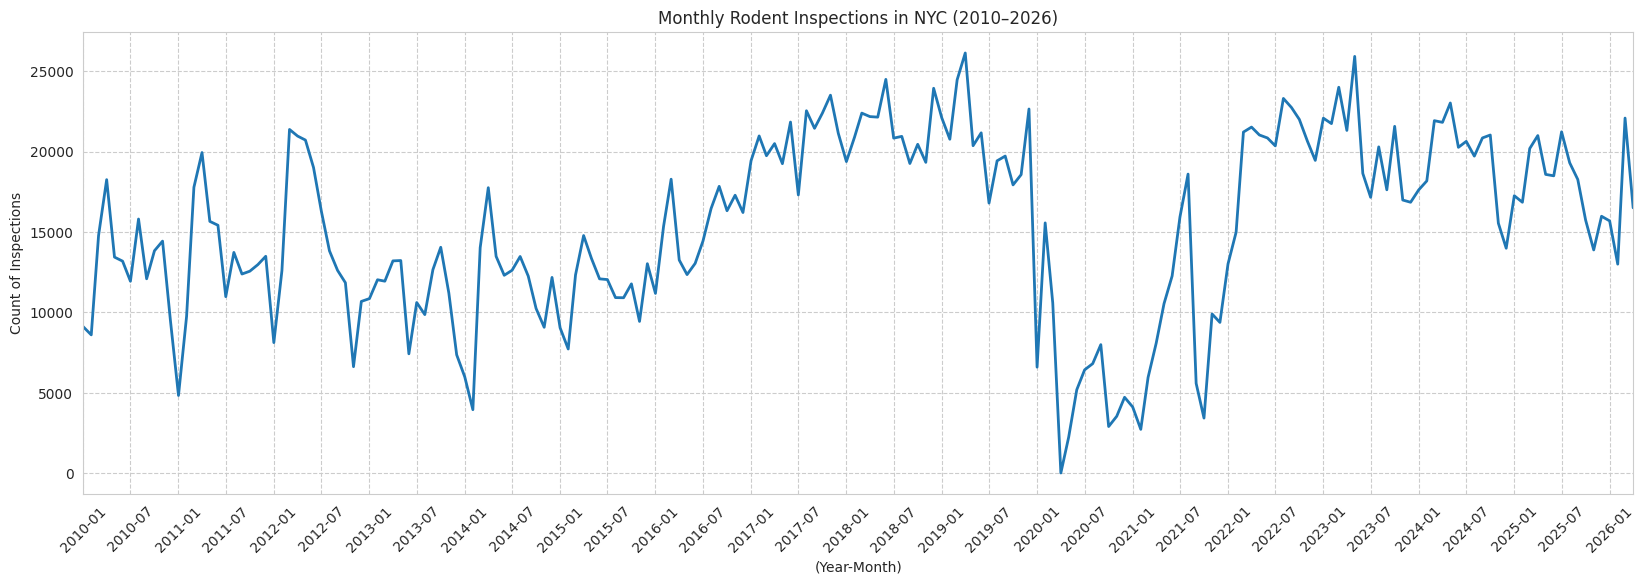

In [ ]:
# Now let's make a line chart showing the monthly inspection count totals over all years

x_axis = "inspection_month_date"
y_axis = "inspection_count"

# set the seaborn style and figure size
sns.set_style("whitegrid", {'grid.linestyle': '--', 'grid.alpha': 0.5})
plt.figure(figsize=(20, 6)) # rectangle instead of square

ax = sns.lineplot(
    inspection_counts_by_month, # this data is sorted by the month_period
    x = x_axis,
    y = y_axis,
    linewidth=2
)

# Set ticks on the x-axis to appear every 6 months (January and July of each year)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,7]))

# Format as "Year-month"
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# angle the tick labels 45 degrees
ax.tick_params(axis='x', labelrotation=45)

# Only show data between min and max inspection dates of my dataset
start_plot = inspection_counts_by_month["inspection_month_date"].min()
end_plot = inspection_counts_by_month["inspection_month_date"].max()
ax.set_xlim(start_plot,end_plot)

plt.title("Monthly Rodent Inspections in NYC (2010–2026)")
plt.xlabel("(Year-Month)")
plt.ylabel("Count of Inspections")

plt.show()

#### The monthly inspection counts show a sharp decline during the COVID period, followed by a recovery to approximately pre-COVID levels by early 2023. After that, the pattern becomes less clear. The lower counts in 2025–2026 are likely influenced by data that has not been reported yet rather than a true decrease in inspection activity.

# Yearly Aggregation Analysis

In [ ]:
# To simplify plotting by year, we add a column that has only the year of the inspection_month_date.
inspection_counts_by_year = inspection_counts_by_month.copy()
inspection_counts_by_year["inspection_year"] = inspection_counts_by_year["inspection_month_date"].dt.year

# use the aggregate_inspection_data function to group the rodent inspections by year and create a table with aggregate result counts
columns_to_group = ["inspection_year"]
type_of_aggregation = "sum"
summary_column_name = "inspection_count"
calculated_column_name = "inspection_count"

inspection_counts_by_year = aggregate_inspection_data(
  df = inspection_counts_by_year,
  grouping_columns = columns_to_group,
  summary_column = summary_column_name,
  aggregation_type = type_of_aggregation,
  output_column_name = calculated_column_name
  )

# Here is the table of Yearly inspection counts to use for plotting
print(inspection_counts_by_year.sort_values("inspection_count", ascending =False))

Grouping the dataframe by ['inspection_year'] to sum values in inspection_count with output column inspection_count
    inspection_year  inspection_count
8              2018            256209
9              2019            250060
7              2017            250019
13             2023            244143
12             2022            241090
14             2024            234550
15             2025            216723
6              2016            181962
2              2012            174600
1              2011            159443
0              2010            154926
5              2015            137356
4              2014            137281
3              2013            134355
11             2021            106441
10             2020             72506
16             2026             67258


In [ ]:
inspection_counts_by_year.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   inspection_year   17 non-null     int32
 1   inspection_count  17 non-null     int64
dtypes: int32(1), int64(1)
memory usage: 336.0 bytes


### Visualization - Create a line plot of Yearly inspection counts

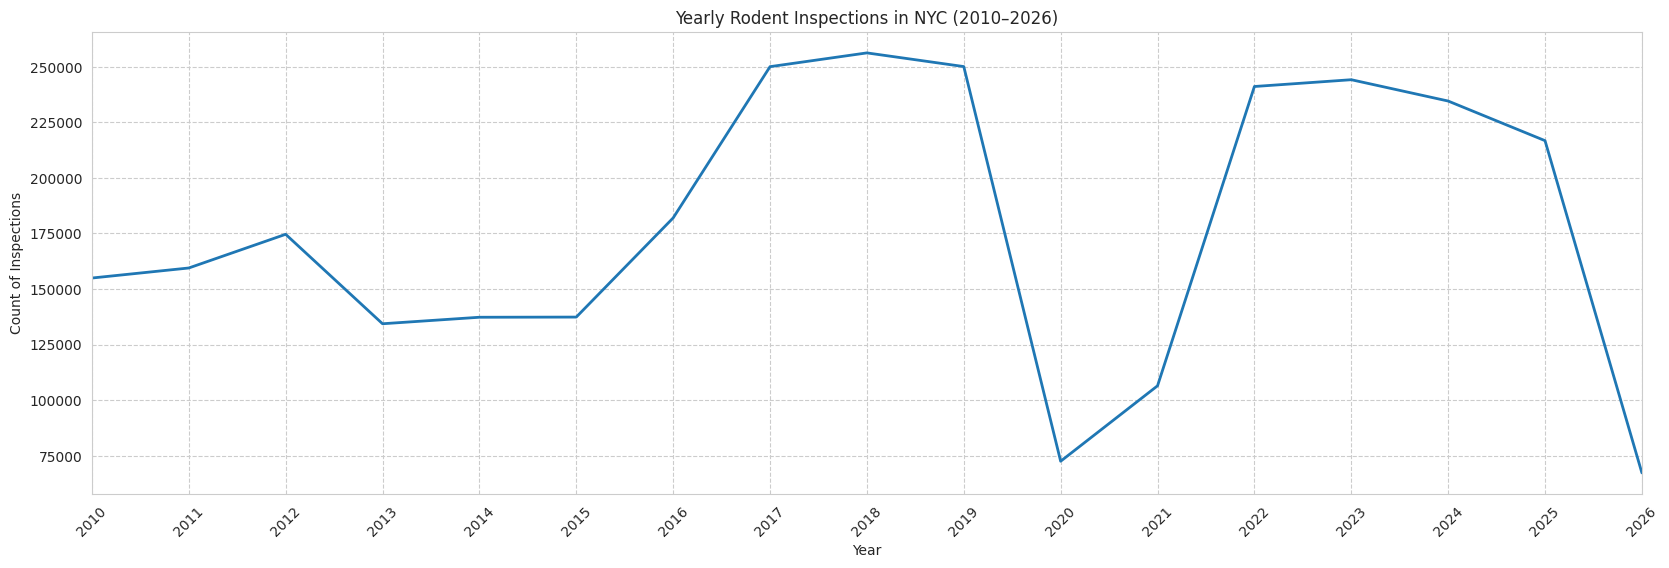

In [ ]:
# Now let's make a line chart showing the yearly inspection count totals

x_axis = "inspection_year"
y_axis = "inspection_count"

# set the seaborn style and figure size
sns.set_style("whitegrid", {'grid.linestyle': '--', 'grid.alpha': 0.5})
plt.figure(figsize=(20, 6)) # rectangle instead of square

ax = sns.lineplot(
    inspection_counts_by_year, # this data is sorted by the inspection year
    x = x_axis,
    y = y_axis,
    linewidth=2
)
# Set ticks on the x-axis to appear every year
# Since Year in this data is an integer, use the ticker.MultipleLocator, not the mdates Locator
ax.xaxis.set_major_locator((MultipleLocator(1)))

# angle the tick labels 45 degrees
ax.tick_params(axis='x', labelrotation=45)

# Only show data between min and max inspection dates of my dataset
start_plot = inspection_counts_by_year["inspection_year"].min()
end_plot = inspection_counts_by_year["inspection_year"].max()
ax.set_xlim(start_plot,end_plot)

plt.title("Yearly Rodent Inspections in NYC (2010–2026)")
plt.xlabel("Year")
plt.ylabel("Count of Inspections")

plt.show()

#### Yearly inspection counts suggest a decline from 2023 through 2025. This needs to be interpreted cautiously, as more recent data may be incomplete. Additional analysis is needed to determine if this reflects a real change in inspection activity or a lag in data reporting.

# Outcome-based Analysis - what were the results of the inspections?

## In this part of the analysis we will do an outcome-based exploration looking at the distribution of Passed vs. Failed inspections over time.

### To facilitate this we will add a new column called "result_group" and set it to "Passed", "Failed", or "Other" depending on the value of the inspection "result" column value.

In [ ]:
# Looking in more detail to see what the possible inspection results are
result_list = list(df_rodents_by_time["result"].unique())

print(f"The unique values for result are:\n {result_list}")

df_rodents_by_time["result"].value_counts(dropna = False, ascending = False)


The unique values for result are:
 ['Bait applied', 'Monitoring visit', 'Cleanup done', 'Stoppage done', 'Failed for Rat Act', 'Passed', 'Failed for Other R', nan, 'Rat Activity']


,count
result,
Passed,1783329
Bait applied,415003
Failed for Rat Act,287956
Failed for Other R,248437
Rat Activity,220880
Monitoring visit,47144
Stoppage done,12750
Cleanup done,3396
NaN,27


### Remove rows with missing result

#### A small number of rows with missing result values will be excluded from the outcome-based analysis, so totals may differ slightly from overall inspection counts.

In [ ]:
# Remove all rows with null result before assigning the result_group category

is_null_result = df_rodents_by_time.result.isnull() == True
print(f"Before the drop, there are {len(df_rodents_by_time[is_null_result])} rows with result=null out of a total of {len(df_rodents_by_time)} in the data.")

df_rodents_by_time = df_rodents_by_time.dropna(axis=0, subset=["result"])

is_null_result = df_rodents_by_time.result.isnull() == True
print(f"After the drop, there are {len(df_rodents_by_time[is_null_result])} rows with result=null out of a total of {len(df_rodents_by_time)} in the data.")

Before the drop, there are 27 rows with result=null out of a total of 3018922 in the data.
After the drop, there are 0 rows with result=null out of a total of 3018895 in the data.


In [ ]:
# confirm the rows with null results are removed
# result_list = list(df_rodents_by_time["result"].unique())
# print(f"After removing the nulls the unique result values are:\n {sorted(result_list)}")
# df_rodents_by_time.value_counts("result", dropna=False)

#### Create a "result_group" column to categorize the inspection "result"

In [ ]:
# create the result_group column
# assign each row one of the three result categories based on the result of the inspection
"""
"Passed" = "Passed"
"Failed" = contains the word "Failed"
"Other" = everything else
"""
# use numpy select to define and set the conditions and categories
# Note: intentionally keeping the SAME dataframe for the outcome-based analysis
df_rodents_by_time["result_group"] = np.select(
    [
        df_rodents_by_time["result"] == "Passed",
        df_rodents_by_time["result"].str.contains("Failed") == True
    ],
    [
        "Passed",
        "Failed"
    ],
    default="Other"
  )

In [ ]:
# checking the new column was added
df_rodents_by_time.shape

(3018895, 24)

In [ ]:
# checking that all rows were assigned a valid value for result_group
df_rodents_by_time["result_group"].value_counts(dropna=False).sort_values(ascending = False)

,count
result_group,
Passed,1783329
Other,699173
Failed,536393


## Analyze Monthly Inspection Counts by Result Group

In [ ]:
# use the aggregate_inspection_data function to group the rodent inspections by month_period and result_group and create a table with aggregate counts
group_cols = [
    "inspection_month_period",
    "result_group"
]
type_of_aggregation = "count"
summary_column_name = "inspection_date"
calculated_column_name = "inspection_count"

monthly_inspection_counts_by_result_group = aggregate_inspection_data(
    df = df_rodents_by_time,
    grouping_columns = group_cols,
    summary_column = summary_column_name,
    aggregation_type = type_of_aggregation,
    output_column_name = calculated_column_name
    )
print(monthly_inspection_counts_by_result_group.sort_values("inspection_count"))

Grouping the dataframe by ['inspection_month_period', 'result_group'] to count values in inspection_date with output column inspection_count
    inspection_month_period result_group  inspection_count
369                 2020-04       Failed                 1
370                 2020-04        Other                 2
371                 2020-05       Failed               226
422                 2021-10       Failed               384
372                 2020-05        Other               437
..                      ...          ...               ...
332                 2019-03       Passed             15617
359                 2019-12       Passed             15657
305                 2018-06       Passed             15753
323                 2018-12       Passed             15884
335                 2019-04       Passed             17697

[587 rows x 3 columns]


### Visualization - create a line plot to show the monthly inspection results over all time periods

In [ ]:
# To simplify plotting by month, we need to add a column that has the inspection_month_period as a datetime. Each "inspection_month_date" will be first day of that inspection_month_period
# for example, if the inspection_month_period is 2025-04, the inspection_month_date will be 2025-04-01

monthly_inspection_counts_by_result_group["inspection_month_date"] = pd.to_datetime(monthly_inspection_counts_by_result_group["inspection_month_period"].astype(str))

In [ ]:
monthly_inspection_counts_by_result_group.dtypes

,0
inspection_month_period,period[M]
result_group,object
inspection_count,int64
inspection_month_date,datetime64[ns]


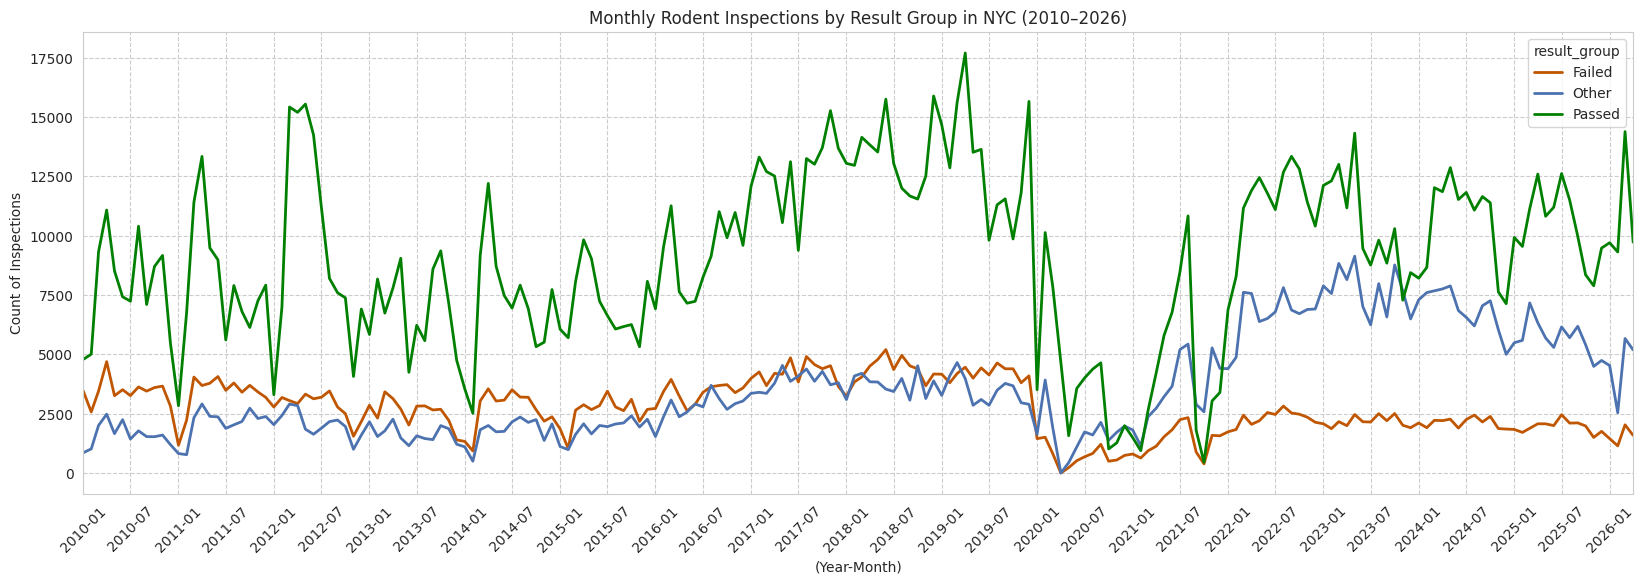

In [ ]:
# Now let's make a line chart showing the monthly inspection count totals over all years

x_axis = "inspection_month_date"
y_axis = "inspection_count"
hue_col = "result_group"

# set the seaborn style and figure size
sns.set_style("whitegrid", {'grid.linestyle': '--', 'grid.alpha': 0.5})
plt.figure(figsize=(20, 6)) # rectangle instead of square

# set the seaborn palette for the hue colors
result_group_palette = {
    "Passed": "green",
    "Failed": "#C05600",   # dark, rich orange
    "Other": "#4C72B0"     # muted blue
}

ax = sns.lineplot(
    monthly_inspection_counts_by_result_group, # this data is sorted by the month_period
    x = x_axis,
    y = y_axis,
    linewidth = 2,
    hue = hue_col,
    palette = result_group_palette
)

# Set ticks on the x-axis to appear every 6 months (January and July of each year)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,7]))

# Format as "Year-month"
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# angle the tick labels 45 degrees
ax.tick_params(axis='x', labelrotation=45)

# Only show data between min and max inspection dates of my dataset
start_plot = inspection_counts_by_month["inspection_month_date"].min()
end_plot = inspection_counts_by_month["inspection_month_date"].max()
ax.set_xlim(start_plot,end_plot)

plt.title("Monthly Rodent Inspections by Result Group in NYC (2010–2026)")
plt.xlabel("(Year-Month)")
plt.ylabel("Count of Inspections")

plt.show()

### The monthly line plot by Result group shows that all inspection categories dropped during the Covid period. Failed inspections stayed down during the Post-Rat Czar period, while Passed inspections recovered and Other inspections increased.

## Analyze Yearly Inspection Counts by Result Group

In [ ]:
# Use the aggregate_inspection_data function to aggregate the monthly result group totals by year
# create a new data frame for grouping the results by year
# add a column with just year of the inspection_month_date for grouping
yearly_inspection_counts_by_result_group = monthly_inspection_counts_by_result_group.copy()

yearly_inspection_counts_by_result_group["year"] = yearly_inspection_counts_by_result_group["inspection_month_date"].dt.year

group_cols = [
    "year",
    "result_group"
]
type_of_aggregation = "sum"
summary_column_name = "inspection_count"
calculated_column_name = "inspection_count"

yearly_inspection_counts_by_result_group = aggregate_inspection_data(
    df = yearly_inspection_counts_by_result_group,
    grouping_columns = group_cols,
    summary_column = summary_column_name,
    aggregation_type = type_of_aggregation,
    output_column_name = calculated_column_name
    )
# check the grouping data before plotting
print(yearly_inspection_counts_by_result_group.head(10))


Grouping the dataframe by ['year', 'result_group'] to sum values in inspection_count with output column inspection_count
   year result_group  inspection_count
0  2010       Failed             41378
1  2010        Other             19325
2  2010       Passed             94219
3  2011       Failed             39955
4  2011        Other             25074
5  2011       Passed             94412
6  2012       Failed             34035
7  2012        Other             24526
8  2012       Passed            116039
9  2013       Failed             31036


### Visualization - Create a line plot of yearly inspection counts by Result group over all time periods

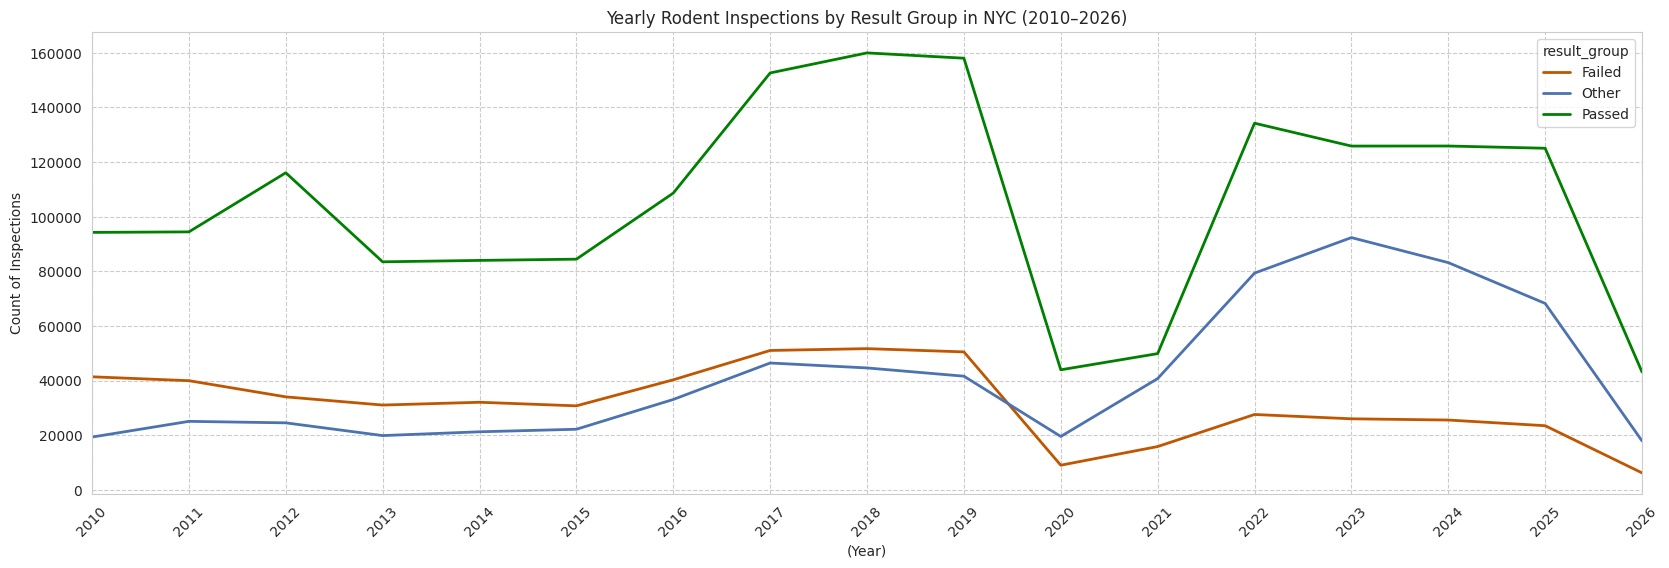

In [ ]:
# Now let's make a line chart showing the result_group totals for each year

x_axis = "year"
y_axis = "inspection_count"
hue_col = "result_group"

# set the seaborn style and figure size
sns.set_style("whitegrid", {'grid.linestyle': '--', 'grid.alpha': 0.5})
plt.figure(figsize=(20, 6)) # rectangle instead of square

# set the seaborn palette for the hue colors
result_group_palette = {
    "Passed": "green",
    "Failed": "#C05600",   # dark, rich orange
    "Other": "#4C72B0"     # muted blue
}

ax = sns.lineplot(
    yearly_inspection_counts_by_result_group, # this data is sorted by year
    x = x_axis,
    y = y_axis,
    linewidth = 2,
    hue = hue_col,
    palette = result_group_palette,
)

# Set ticks on the x-axis to appear every year
ax.xaxis.set_major_locator(MultipleLocator(1))

# angle the tick labels 45 degrees
ax.tick_params(axis='x', labelrotation=45)

# Only show data between min and max inspection dates of my dataset
start_plot = yearly_inspection_counts_by_result_group["year"].min()
end_plot = yearly_inspection_counts_by_result_group["year"].max()
ax.set_xlim(start_plot,end_plot)

plt.title("Yearly Rodent Inspections by Result Group in NYC (2010–2026)")
plt.xlabel("(Year)")
plt.ylabel("Count of Inspections")

plt.show()

### The yearly line plot by Result group clearly shows that all inspection categories dropped during the Covid period. Failed inspections increased somewhat during the recovery years but remained below pre-COVID levels. Passed inspections increased rapidly, then plateaued during the Post-Rat Czar period, while Other inspections rose more slowly and declined during the Post-Rat Czar period.
Further analysis by inspection_type (e.g., Initial vs. Compliance inspections) would help determine whether changes in “Other” inspections reflect shifts in inspection activity or differences in inspection outcomes.

# Question: What percentage of each time period was Passed / Failed / Other?
### To better compare inspection outcomes across time periods of different sizes, I calculated the percentage distribution of results (Passed, Failed, Other) within each period.

In [ ]:
# group the data by Time Period and Result Group
# df_rodents_by_time.head(1)

In [ ]:
# In order to calculate the percentages, first use aggregate_inspection_data function to get the inspection counts by time_period and result_group, then calculate the total for each time period regardless of result group

# Use aggregate_inspection_data function to count inspections by time period and result group
columns_to_group = [
    "time_period",
    "result_group"
    ]
type_of_aggregation = "count"
summary_column_name = "inspection_date"
calculated_column_name = "inspection_count"

time_period_result_counts = aggregate_inspection_data(
    df = df_rodents_by_time,
    grouping_columns = columns_to_group,
    summary_column = summary_column_name,
    aggregation_type = type_of_aggregation,
    output_column_name = calculated_column_name
    )
print(f"Inspection counts grouped by time period and result category:\n{time_period_result_counts}")

# sum up the total inspections within each time period and add this column
# to each result group row so that percentages can be calculated
time_period_result_counts["time_period_total"] = (
    time_period_result_counts
    .groupby("time_period")["inspection_count"]
    .transform("sum") # leaves the result_group row details in the df and puts the same time_period summed total on each one
)
print()
print(f"Added time period total to each result category:\n{time_period_result_counts}")

# add a column with the percentage
# for each result_group, calculate percentage of that time period
time_period_result_counts["result_group_percent"] = (
    time_period_result_counts["inspection_count"]
    / time_period_result_counts["time_period_total"]
)
print()
print(f"Added percentage of time period to each result category:\n{time_period_result_counts}")

# sanity check percentage totals
print(f"(Confirmed percentage totals within each time period equals 100:\n{time_period_result_counts.groupby("time_period")["result_group_percent"].sum().round(4)}\n)")
print()
print("This is the table we will use for charting the distribution result categories within each time period:")
time_period_result_counts.sort_values(["time_period", "result_group_percent"], ascending=[True, False]).round(3)

Grouping the dataframe by ['time_period', 'result_group'] to count values in inspection_date with output column inspection_count
Inspection counts grouped by time period and result category:
        time_period result_group  inspection_count
0  COVID / Recovery       Failed             55615
1  COVID / Recovery        Other            158312
2  COVID / Recovery       Passed            251764
3     Post Rat Czar       Failed             75146
4     Post Rat Czar        Other            237354
5     Post Rat Czar       Passed            382356
6         Pre-COVID       Failed            405632
7         Pre-COVID        Other            303507
8         Pre-COVID       Passed           1149209

Added time period total to each result category:
        time_period result_group  inspection_count  time_period_total
0  COVID / Recovery       Failed             55615             465691
1  COVID / Recovery        Other            158312             465691
2  COVID / Recovery       Passed       

,time_period,result_group,inspection_count,time_period_total,result_group_percent
2,COVID / Recovery,Passed,251764,465691,0.541
1,COVID / Recovery,Other,158312,465691,0.340
0,COVID / Recovery,Failed,55615,465691,0.119
5,Post Rat Czar,Passed,382356,694856,0.550
4,Post Rat Czar,Other,237354,694856,0.342
3,Post Rat Czar,Failed,75146,694856,0.108
8,Pre-COVID,Passed,1149209,1858348,0.618
6,Pre-COVID,Failed,405632,1858348,0.218
7,Pre-COVID,Other,303507,1858348,0.163


### Visualization - Create a bar chart showing the percentages for each of the three result groups within each time period

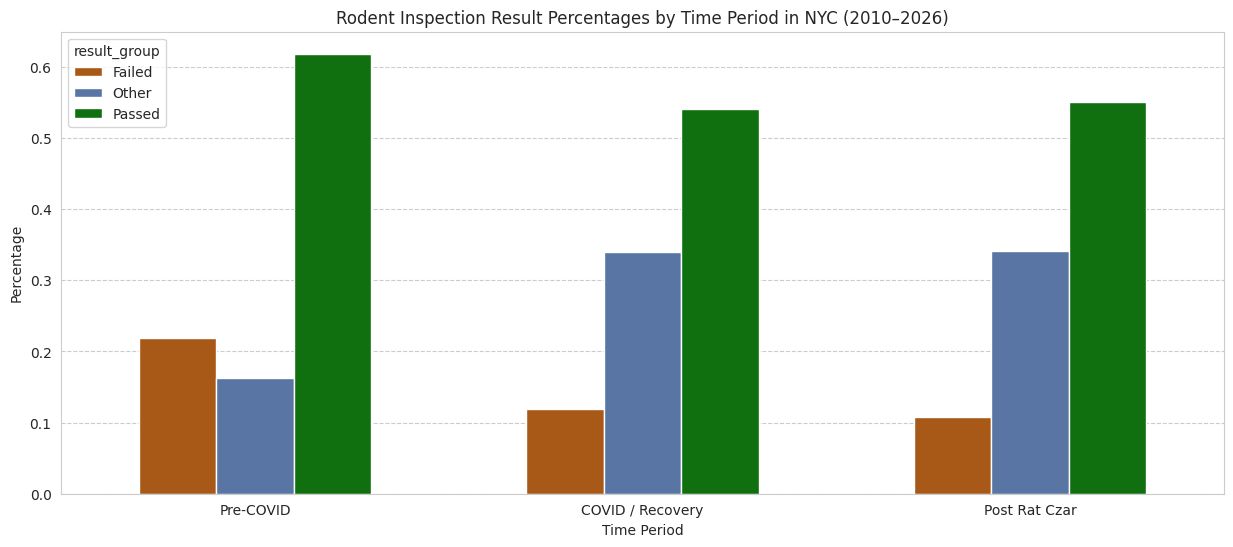

In [ ]:
# Create a bar chart showing the percentages of each result group within each time period
x_axis = "time_period"
y_axis = "result_group_percent"
hue_col = "result_group"

# set the seaborn style and figure size
sns.set_style("whitegrid", {'grid.linestyle': '--', 'grid.alpha': 0.5})
plt.figure(figsize=(15, 6)) # rectangle instead of square

# set the seaborn palette for the hue colors
result_group_palette = {
    "Passed": "green",
    "Failed": "#C05600",   # dark, rich orange
    "Other": "#4C72B0"     # muted blue
}

ax = sns.barplot(
    time_period_result_counts,
    x = x_axis,
    y = y_axis,
    hue = hue_col,
    palette = result_group_palette,
    width = 0.6,
    order=["Pre-COVID", "COVID / Recovery", "Post Rat Czar"]
)

plt.title("Rodent Inspection Result Percentages by Time Period in NYC (2010–2026)")
plt.xlabel("Time Period")
plt.ylabel("Percentage")

plt.show()

## Conclusion

### The bar chart shows that the percentage of Failed inspections decreased from the Pre-COVID period to the Post–Rat Czar period, while the percentage of Other inspections increased substantially over the same time. In the COVID/Recovery and Post–Rat Czar periods, Other inspections are nearly as common as Passed inspections, indicating a shift in the distribution of outcomes. Passed inspections remain the largest category overall, with a slight increase in the Post–Rat Czar period.

#### These results should be interpreted cautiously. Although percentages adjust for differences in total inspection counts, the time periods vary in length and the most recent data may be incomplete. In addition, inspection counts reflect multiple types of activity (e.g., initial inspections, compliance checks, and treatments), not just new complaints, and may be influenced by broader mitigation efforts such as waste management initiatives.

#### Overall, the results suggest a shift away from Failed outcomes and toward Other inspection outcomes, though further analysis by inspection type would be needed to better understand what is driving these changes.

#### As of this analysis, there is no current rat czar, and future trends may depend on how rodent mitigation efforts are prioritized by the current administration.